In [1]:
pip install seaborn

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scikit-learn

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
print("Python executable:", sys.executable)
import subprocess
subprocess.run([sys.executable, "-m", "pip", "show", "numpy"])

Python executable: /environment/miniconda3/bin/python
Name: numpy
Version: 2.4.4
Summary: Fundamental package for array computing in Python
Home-page: 
Author: Travis E. Oliphant et al.
Author-email: 
License: 
Location: /environment/miniconda3/lib/python3.11/site-packages
Requires: 
Required-by: contourpy, h5py, keras, matplotlib, ml-dtypes, numba, opt-einsum, pandas, scikit-learn, scipy, seaborn, shap, tensorboard, tensorflow, torchvision


CompletedProcess(args=['/environment/miniconda3/bin/python', '-m', 'pip', 'show', 'numpy'], returncode=0)

In [4]:
!pip uninstall numpy -y
!pip install numpy

Found existing installation: numpy 2.4.4
Uninstalling numpy-2.4.4:
  Successfully uninstalled numpy-2.4.4
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 87.4 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.1 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.4.4 which is incompatible.


#Imports and Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Set graphic style
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/environment/miniconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/environment/miniconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/environment/miniconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/environ

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


#Data Loading

In [7]:
# Step 1: Data Loading and Preprocessing
# Load both datasets
train_df = pd.read_csv('data/survey lung cancer.csv')
valid_df = pd.read_csv('data/cancer patient data sets.csv')

print("Training data shape:", train_df.shape)
print("Validation data shape:", valid_df.shape)

Training data shape: (309, 16)
Validation data shape: (1000, 26)


#Feature Mapping and Preprocessing

In [8]:
# Step 2: Merge both datasets
# Define feature mapping for validation set
feature_mapping = {}
if 'Gender' in valid_df.columns:
    feature_mapping['Gender'] = 'GENDER'
if 'Age' in valid_df.columns:
    feature_mapping['Age'] = 'AGE'
if 'Smoking' in valid_df.columns:
    feature_mapping['Smoking'] = 'SMOKING'
if 'Alcohol usé' in valid_df.columns:
    feature_mapping['Alcohol usé'] = 'ALCOHOL_CONSUMING'
if 'Coughing' in valid_df.columns:
    feature_mapping['Coughing'] = 'COUGHING'
if 'Shortness of Breath' in valid_df.columns:
    feature_mapping['Shortness of Breath'] = 'SHORTNESS_OF_BREATH'
elif 'Shortness' in valid_df.columns:
    feature_mapping['Shortness'] = 'SHORTNESS_OF_BREATH'
if 'Chest Pain' in valid_df.columns:
    feature_mapping['Chest Pain'] = 'CHEST_PAIN'
if 'Wheezing' in valid_df.columns:
    feature_mapping['Wheezing'] = 'WHEEZING'

print("Feature mapping:", feature_mapping)

# Training data features
train_features = []
if 'GENDER' in train_df.columns:
    train_features.append('GENDER')
if 'AGE' in train_df.columns:
    train_features.append('AGE')
if 'SMOKING' in train_df.columns:
    train_features.append('SMOKING')
if 'ALCOHOL CONSUMING' in train_df.columns:
    train_features.append('ALCOHOL CONSUMING')
if 'COUGHING' in train_df.columns:
    train_features.append('COUGHING')
if 'SHORTNESS OF BREATH' in train_df.columns:
    train_features.append('SHORTNESS OF BREATH')
if 'CHEST PAIN' in train_df.columns:
    train_features.append('CHEST PAIN')
if 'WHEEZING' in train_df.columns:
    train_features.append('WHEEZING')

# Standardize format for training set
rename_dict = {}
if 'ALCOHOL CONSUMING' in train_df.columns:
    rename_dict['ALCOHOL CONSUMING'] = 'ALCOHOL_CONSUMING'
if 'SHORTNESS OF BREATH' in train_df.columns:
    rename_dict['SHORTNESS OF BREATH'] = 'SHORTNESS_OF_BREATH'
if 'CHEST PAIN' in train_df.columns:
    rename_dict['CHEST PAIN'] = 'CHEST_PAIN'

train_df_processed = train_df.rename(columns=rename_dict)

# Update training feature list with renamed columns
train_features_processed = []
for feature in train_features:
    if feature in rename_dict:
        train_features_processed.append(rename_dict[feature])
    else:
        train_features_processed.append(feature)

print("Training features:", train_features_processed)

Feature mapping: {'Gender': 'GENDER', 'Age': 'AGE', 'Smoking': 'SMOKING', 'Shortness of Breath': 'SHORTNESS_OF_BREATH', 'Chest Pain': 'CHEST_PAIN', 'Wheezing': 'WHEEZING'}
Training features: ['GENDER', 'AGE', 'SMOKING', 'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH', 'CHEST_PAIN', 'WHEEZING']


#Validation Set Processing

In [9]:
# Preprocess validation set
valid_df_processed = valid_df.rename(columns=feature_mapping)

# Transform target variable for validation set
valid_df_processed['LUNG_CANCER'] = valid_df_processed['Level'].map({
    'High': 1, 'Medium': 1, 'Low': 0
})

# Identify common features
valid_features_exist = [f for f in feature_mapping.values() if f in valid_df_processed.columns]
common_features = list(set(train_features_processed) & set(valid_features_exist))
print("Common features:", common_features)

# Select only common features from both datasets
train_df_common = train_df_processed[common_features + ['LUNG_CANCER']]
valid_df_common = valid_df_processed[common_features + ['LUNG_CANCER']]

Common features: ['GENDER', 'SHORTNESS_OF_BREATH', 'CHEST_PAIN', 'SMOKING', 'AGE', 'WHEEZING']


#Data Type Consistency and Merging

In [10]:
# Step 2.1: Ensure consistent data types before merging
print("\nBefore merging - Training set LUNG_CANCER dtype:", train_df_common['LUNG_CANCER'].dtype)
print("Before merging - Validation set LUNG_CANCER dtype:", valid_df_common['LUNG_CANCER'].dtype)

# Convert target variable to consistent numeric type
if train_df_common['LUNG_CANCER'].dtype == 'object':
    train_df_common['LUNG_CANCER'] = train_df_common['LUNG_CANCER'].map({'YES': 1, 'NO': 0})
train_df_common['LUNG_CANCER'] = train_df_common['LUNG_CANCER'].astype(int)

valid_df_common['LUNG_CANCER'] = valid_df_common['LUNG_CANCER'].astype(int)

print("After conversion - Training set LUNG_CANCER dtype:", train_df_common['LUNG_CANCER'].dtype)
print("After conversion - Validation set LUNG_CANCER dtype:", valid_df_common['LUNG_CANCER'].dtype)

# Step 2.2: Ensure consistent GENDER data type
print("\nBefore merging - Training set GENDER unique values:", train_df_common['GENDER'].unique())
print("Before merging - Validation set GENDER unique values:", valid_df_common['GENDER'].unique())

# Convert GENDER to string type in both datasets
train_df_common['GENDER'] = train_df_common['GENDER'].astype(str)
valid_df_common['GENDER'] = valid_df_common['GENDER'].astype(str)

# Map numeric gender codes to consistent string format
# Check if validation set uses numeric codes (1, 2) for gender
if set(valid_df_common['GENDER'].unique()) == {'1', '2'}:
    valid_df_common['GENDER'] = valid_df_common['GENDER'].map({'1': 'M', '2': 'F'})

print("After conversion - Training set GENDER unique values:", train_df_common['GENDER'].unique())
print("After conversion - Validation set GENDER unique values:", valid_df_common['GENDER'].unique())

# Combine both datasets
combined_df = pd.concat([train_df_common, valid_df_common], ignore_index=True)

print(f"Combined dataset shape: {combined_df.shape}")
print("Combined dataset LUNG_CANCER dtype:", combined_df['LUNG_CANCER'].dtype)
print("Combined dataset GENDER unique values:", combined_df['GENDER'].unique())


Before merging - Training set LUNG_CANCER dtype: object
Before merging - Validation set LUNG_CANCER dtype: int64
After conversion - Training set LUNG_CANCER dtype: int64
After conversion - Validation set LUNG_CANCER dtype: int64

Before merging - Training set GENDER unique values: ['M' 'F']
Before merging - Validation set GENDER unique values: [1 2]
After conversion - Training set GENDER unique values: ['M' 'F']
After conversion - Validation set GENDER unique values: ['M' 'F']
Combined dataset shape: (1309, 7)
Combined dataset LUNG_CANCER dtype: int64
Combined dataset GENDER unique values: ['M' 'F']


#Feature Selection and Encoding

In [11]:
# Step 4: Data Preprocessing for Combined Dataset
# Select features and target
X = combined_df[common_features]
y = combined_df['LUNG_CANCER']

# Process target variable - already done above, but double-check
print("Target variable unique values before processing:", y.unique())
print("Target variable dtype before processing:", y.dtype)

# Ensure target is integer type
y = y.astype(int)
print("Target variable unique values after processing:", y.unique())
print("Target variable dtype after processing:", y.dtype)

# Process gender encoding - FIXED TYPE ISSUE
if 'GENDER' in X.columns:
    print("GENDER column unique values before encoding:", X['GENDER'].unique())
    print("GENDER column dtype before encoding:", X['GENDER'].dtype)
    
    # Ensure GENDER is string type
    X['GENDER'] = X['GENDER'].astype(str)
    
    # Standardize gender values
    X['GENDER'] = X['GENDER'].map({
        'M': 'M', 'F': 'F', 
        '1': 'M', '2': 'F',
        'Male': 'M', 'Female': 'F'
    }).fillna(X['GENDER'])  # Keep original value if not in mapping
    
    print("GENDER column unique values after standardization:", X['GENDER'].unique())
    
    le = LabelEncoder()
    X['GENDER'] = le.fit_transform(X['GENDER'])
    print("GENDER column unique values after encoding:", np.unique(X['GENDER']))

Target variable unique values before processing: [1 0]
Target variable dtype before processing: int64
Target variable unique values after processing: [1 0]
Target variable dtype after processing: int64
GENDER column unique values before encoding: ['M' 'F']
GENDER column dtype before encoding: object
GENDER column unique values after standardization: ['M' 'F']
GENDER column unique values after encoding: [0 1]


#Train-Test Split and Scaling

In [12]:
# Split data into 60% training and 40% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Data standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing completed!")

Training set shape: (785, 6)
Testing set shape: (524, 6)
Data preprocessing completed!


#Neural Network Model Definitions

In [13]:
# Step 5: Enhanced Model Building with Attention and CNN - FIXED VERSION
class AttentionModule(nn.Module):
    """Attention mechanism to focus on important features"""
    def __init__(self, feature_dim):
        super(AttentionModule, self).__init__()
        self.attention_weights = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.Tanh(),
            nn.Linear(feature_dim, 1),
            nn.Softmax(dim=1)
        )
        
    def forward(self, x):
        # x shape: (batch_size, feature_dim)
        attention_scores = self.attention_weights(x)  # (batch_size, 1)
        weighted_features = x * attention_scores  # Element-wise multiplication
        return weighted_features, attention_scores

class CNNFeatureExtractor(nn.Module):
    """CNN for extracting local patterns from features"""
    def __init__(self, input_dim, output_dim=32):
        super(CNNFeatureExtractor, self).__init__()
        # Reshape features to 2D for CNN (batch_size, 1, input_dim)
        self.conv1d = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(32, output_dim)
        
    def forward(self, x):
        # x shape: (batch_size, input_dim)
        x = x.unsqueeze(1)  # (batch_size, 1, input_dim)
        x = self.conv1d(x)  # (batch_size, 32, 1)
        x = x.squeeze(-1)   # (batch_size, 32)
        x = self.fc(x)      # (batch_size, output_dim)
        return x

class EnhancedTemporalCausalNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_treatments=3, sequence_length=5, 
                 use_attention=True, use_cnn=True):
        super(EnhancedTemporalCausalNetwork, self).__init__()
        self.input_dim = input_dim
        self.sequence_length = sequence_length
        self.num_treatments = num_treatments
        self.use_attention = use_attention
        self.use_cnn = use_cnn
        
        # CNN Feature Extractor
        if use_cnn:
            self.cnn_extractor = CNNFeatureExtractor(input_dim, hidden_dim // 2)
            cnn_output_dim = hidden_dim // 2
        else:
            cnn_output_dim = 0
        
        # Attention Mechanism
        if use_attention:
            self.attention = AttentionModule(input_dim)
        
        # Patient state encoder (LSTM for temporal patterns)
        # FIXED: Ensure proper input dimension calculation
        lstm_input_dim = input_dim
        if use_attention:
            lstm_input_dim += input_dim  # Add attended features
        if use_cnn:
            lstm_input_dim += cnn_output_dim  # Add CNN features
            
        self.state_encoder = nn.LSTM(lstm_input_dim, hidden_dim, batch_first=True, dropout=0.2)
        
        # Treatment effect network
        self.treatment_encoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.3)
        )
        
        # Causal mechanism: treatment + patient state -> outcome
        self.causal_mechanism = nn.Sequential(
            nn.Linear(hidden_dim + num_treatments, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()  # Ensure output is in [0,1] range
        )
        
        # Propensity network for treatment assignment
        self.propensity_net = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_treatments),
            nn.Softmax(dim=1)
        )
        
    def forward(self, x, treatment=None, return_components=False):
        # Ensure proper input dimensions
        if len(x.shape) == 1:
            x = x.unsqueeze(0)
        
        original_x = x.clone()  # Keep original features
        
        # Apply attention if enabled
        if self.use_attention:
            x_attended, attention_scores = self.attention(x)
            # Combine original features with attended features
            x = torch.cat([original_x, x_attended], dim=1)
        
        # Extract CNN features if enabled
        cnn_features = None
        if self.use_cnn:
            cnn_features = self.cnn_extractor(original_x)
            # Combine with current features
            if self.use_attention:
                x = torch.cat([x, cnn_features], dim=1)
            else:
                x = torch.cat([original_x, cnn_features], dim=1)
        
        # For static data, create temporal patterns
        if len(x.shape) == 2:
            batch_size, input_dim = x.shape
            x = x.unsqueeze(1).repeat(1, self.sequence_length, 1)
            noise = torch.randn_like(x) * 0.01
            x = x + noise
        
        # Encode patient state over time
        encoded_states, (hidden, cell) = self.state_encoder(x)
        patient_representation = hidden[-1]
        
        # Treatment encoding
        state_encoded = self.treatment_encoder(patient_representation)
        
        if treatment is None:
            treatment_probs = self.propensity_net(patient_representation)
            return treatment_probs
        else:
            # Ensure treatment has proper dimensions
            if len(treatment.shape) == 1:
                treatment = treatment.unsqueeze(0)
            
            treatment_effect = self.causal_mechanism(
                torch.cat([state_encoded, treatment], dim=1)
            )
            
            # FIXED: Ensure output is in valid range for BCE loss
            treatment_effect = torch.clamp(treatment_effect, 1e-7, 1-1e-7)
            
            if return_components:
                return {
                    'treatment_effect': treatment_effect,
                    'patient_representation': patient_representation,
                    'state_encoded': state_encoded
                }
            return treatment_effect
    
    def estimate_ate(self, x, treatments=None):
        # Estimate Average Treatment Effect for different treatments
        if len(x.shape) == 1:
            x = x.unsqueeze(0)
    
        batch_size = x.shape[0]
        device = x.device  
    
        if treatments is None:
            treatments = torch.eye(self.num_treatments, device=device)  
    
        outcomes = []
        for treatment in treatments:
            treatment_expanded = treatment.unsqueeze(0)
            if batch_size > 1:
                treatment_expanded = treatment_expanded.repeat(batch_size, 1)
    
            outcome = self.forward(x, treatment_expanded)
            outcomes.append(outcome)
    
        return torch.stack(outcomes, dim=1)
    
    def counterfactual_prediction(self, x, current_treatment, alternative_treatment):
        """What-if analysis: predict outcome under alternative treatment"""
        if len(x.shape) == 1:
            x = x.unsqueeze(0)
        
        batch_size = x.shape[0]
        
        # Ensure treatments have proper dimensions
        if len(current_treatment.shape) == 1:
            current_treatment = current_treatment.unsqueeze(0)
        if len(alternative_treatment.shape) == 1:
            alternative_treatment = alternative_treatment.unsqueeze(0)
        
        # Repeat treatments to match batch size if needed
        if current_treatment.shape[0] == 1 and batch_size > 1:
            current_treatment = current_treatment.repeat(batch_size, 1)
        if alternative_treatment.shape[0] == 1 and batch_size > 1:
            alternative_treatment = alternative_treatment.repeat(batch_size, 1)
        
        current_outcome = self.forward(x, current_treatment)
        alternative_outcome = self.forward(x, alternative_treatment)
        
        return {
            'current_outcome': current_outcome,
            'alternative_outcome': alternative_outcome,
            'treatment_effect': alternative_outcome - current_outcome
        }

#Data Preparation for Training

In [14]:
# Convert to PyTorch tensors and move to device
X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)
y_train_values = y_train.values.astype(np.float32)
y_test_values = y_test.values.astype(np.float32)

# Keep the CPU tensor for the DataLoader
X_train_tensor_cpu = torch.FloatTensor(X_train_scaled)
y_train_tensor_cpu = torch.FloatTensor(y_train_values).reshape(-1, 1)
X_test_tensor_cpu = torch.FloatTensor(X_test_scaled)
y_test_tensor_cpu = torch.FloatTensor(y_test_values).reshape(-1, 1)

# Create GPU tensors for model evaluation (which will also be used during training)
X_train_tensor = X_train_tensor_cpu.to(device)
y_train_tensor = y_train_tensor_cpu.to(device)
X_test_tensor = X_test_tensor_cpu.to(device)
y_test_tensor = y_test_tensor_cpu.to(device)

print("Tensor shapes:")
print("X_train_tensor (CPU):", X_train_tensor_cpu.shape)
print("y_train_tensor (CPU):", y_train_tensor_cpu.shape)
print("X_test_tensor (CPU):", X_test_tensor_cpu.shape)
print("y_test_tensor (CPU):", y_test_tensor_cpu.shape)
print("X_train_tensor (GPU):", X_train_tensor.shape)
print("X_test_tensor (GPU):", X_test_tensor.shape)
print(f"Device: {X_train_tensor.device}")

# Create a DataLoader using CPU tensors, and set num_workers to 0 (to avoid CUDA subprocess issues)
train_dataset = TensorDataset(X_train_tensor_cpu, y_train_tensor_cpu)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

Tensor shapes:
X_train_tensor (CPU): torch.Size([785, 6])
y_train_tensor (CPU): torch.Size([785, 1])
X_test_tensor (CPU): torch.Size([524, 6])
y_test_tensor (CPU): torch.Size([524, 1])
X_train_tensor (GPU): torch.Size([785, 6])
X_test_tensor (GPU): torch.Size([524, 6])
Device: cuda:0


#Model Initialization

In [15]:
# Enhanced Model initialization with more conservative settings
input_dim = X_train_scaled.shape[1]
model = EnhancedTemporalCausalNetwork(
    input_dim=input_dim,
    hidden_dim=64,  # Reduced hidden dimension for stability
    num_treatments=3,  
    sequence_length=5,
    use_attention=True,
    use_cnn=True
).to(device)  

print(f"Enhanced model with Attention and CNN initialized")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Model device: {next(model.parameters()).device}")

treatment_options = torch.eye(3) 

# Enhanced loss function with better numerical stability
def enhanced_causal_loss(predicted, actual, patient_representation, treatment, 
                        alpha=0.1, beta=0.001, gamma=0.0001):
    # FIXED: Add numerical stability to BCE loss
    predicted = torch.clamp(predicted, 1e-7, 1-1e-7)
    prediction_loss = nn.BCELoss()(predicted, actual)

    batch_size = patient_representation.shape[0]
    if batch_size > 1:
        rep_std = torch.std(patient_representation, dim=0)
        balance_loss = torch.mean(rep_std)
    else:
        balance_loss = torch.tensor(0.0, device=predicted.device)  

    # Add L2 regularization
    l2_reg = torch.tensor(0.0, device=predicted.device) 
    for param in model.parameters():
        l2_reg += torch.norm(param)

    total_loss = prediction_loss + alpha * balance_loss + beta * l2_reg
    return total_loss

criterion = enhanced_causal_loss
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5) 

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)

Enhanced model with Attention and CNN initialized
Total parameters: 52629
Model device: cuda:0


#Training Setup

In [16]:
# Step 6: Enhanced Model Training with Early Stopping
epochs = 100  # Reduced epochs
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
treatment_effects = []
learning_rates = []

# Early stopping parameters
best_test_loss = float('inf')
best_test_accuracy = 0.0
patience = 15
patience_counter = 0
best_model_state = None

#Training Loop

In [17]:
for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()

        batch_size = batch_X.shape[0]
        simulated_treatment = torch.randint(0, 3, (batch_size,), device=device)  
        treatment_one_hot = torch.eye(3, device=device)[simulated_treatment]      

        outputs_dict = model(batch_X, treatment_one_hot, return_components=True)
        predicted_outcome = outputs_dict['treatment_effect']
        patient_rep = outputs_dict['patient_representation']
        
        # FIXED: Check for NaN or Inf values
        if torch.isnan(predicted_outcome).any() or torch.isinf(predicted_outcome).any():
            print(f"Warning: NaN or Inf detected in predictions at epoch {epoch}")
            continue
            
        loss = criterion(predicted_outcome, batch_y, patient_rep, treatment_one_hot)
        
        # FIXED: Check for NaN loss
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Warning: NaN or Inf loss at epoch {epoch}")
            continue
            
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        predicted = (predicted_outcome > 0.5).float()
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()
    
    # Validation on test set
    model.eval()
    with torch.no_grad():
        test_batch_size = X_test_tensor.shape[0]
        test_treatment = torch.randint(0, 3, (test_batch_size,), device=device)
        test_treatment_one_hot = torch.eye(3, device=device)[test_treatment]
        
        test_outputs_dict = model(X_test_tensor, test_treatment_one_hot, return_components=True)
        test_predicted = test_outputs_dict['treatment_effect']
        
        # FIXED: Check for NaN or Inf in validation
        if torch.isnan(test_predicted).any() or torch.isinf(test_predicted).any():
            print(f"Warning: NaN or Inf in validation at epoch {epoch}")
            test_loss = torch.tensor(float('inf'))
            test_accuracy = 0.0
        else:
            test_loss = criterion(test_predicted, y_test_tensor, 
                               test_outputs_dict['patient_representation'], test_treatment_one_hot)
            
            test_predicted_binary = (test_predicted > 0.5).float()
            test_accuracy = (test_predicted_binary == y_test_tensor).sum().item() / len(y_test_tensor)
        
        # Calculate average treatment effects
        ate = model.estimate_ate(X_test_tensor)
        treatment_effects.append(ate.mean().item())
    
    # Update learning rate
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    # Only step scheduler if loss is valid
    if not torch.isinf(test_loss) and not torch.isnan(test_loss):
        scheduler.step(test_loss)
    
    # Record metrics
    train_losses.append(train_loss / len(train_loader))
    test_losses.append(test_loss.item() if not torch.isinf(test_loss) and not torch.isnan(test_loss) else float('inf'))
    train_accuracies.append(train_correct / train_total)
    test_accuracies.append(test_accuracy)
    
    # Early stopping check
    if test_accuracy > best_test_accuracy and not torch.isinf(test_loss) and not torch.isnan(test_loss):
        best_test_accuracy = test_accuracy
        best_test_loss = test_loss.item()
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"New best model saved with test accuracy: {best_test_accuracy:.4f}")
    else:
        patience_counter += 1
    
    # 每个epoch都打印结果
    print(f'Epoch [{epoch+1:2d}/{epochs}], Train Loss: {train_loss/len(train_loader):.4f}, '
          f'Test Loss: {test_loss.item() if not torch.isinf(test_loss) and not torch.isnan(test_loss) else "N/A":.4f}, '
          f'Train Acc: {train_correct/train_total:.4f}, '
          f'Test Acc: {test_accuracy:.4f}, LR: {current_lr:.6f}')
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        # Load the best model
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
        break
np.savez('training_history.npz',
         train_losses=train_losses,
         test_losses=test_losses,
         train_accuracies=train_accuracies,
         test_accuracies=test_accuracies,
         learning_rates=learning_rates,
         treatment_effects=treatment_effects)
print("Training history saved to training_history.npz")

print("\n" + "="*70)
print("TRAINING SUMMARY")
print("="*70)
print(f"Total epochs completed: {len(train_losses)}")
print(f"Best test accuracy: {best_test_accuracy:.4f}")
print(f"Final test accuracy: {test_accuracies[-1]:.4f}")
print(f"Early stopping: {'Yes' if len(train_losses) < epochs else 'No'}")

New best model saved with test accuracy: 0.7385
Epoch [ 1/100], Train Loss: 0.6554, Test Loss: 0.6960, Train Acc: 0.7834, Test Acc: 0.7385, LR: 0.001000
New best model saved with test accuracy: 0.9256
Epoch [ 2/100], Train Loss: 0.4561, Test Loss: 0.4270, Train Acc: 0.8917, Test Acc: 0.9256, LR: 0.001000
Epoch [ 3/100], Train Loss: 0.3452, Test Loss: 0.3072, Train Acc: 0.9121, Test Acc: 0.9256, LR: 0.001000
New best model saved with test accuracy: 0.9370
Epoch [ 4/100], Train Loss: 0.3029, Test Loss: 0.2761, Train Acc: 0.9325, Test Acc: 0.9370, LR: 0.001000
New best model saved with test accuracy: 0.9408
Epoch [ 5/100], Train Loss: 0.2808, Test Loss: 0.2606, Train Acc: 0.9338, Test Acc: 0.9408, LR: 0.001000
New best model saved with test accuracy: 0.9504
Epoch [ 6/100], Train Loss: 0.2690, Test Loss: 0.2611, Train Acc: 0.9338, Test Acc: 0.9504, LR: 0.001000
Epoch [ 7/100], Train Loss: 0.2480, Test Loss: 0.2516, Train Acc: 0.9490, Test Acc: 0.9485, LR: 0.001000
Epoch [ 8/100], Train Los

#Training Visualization

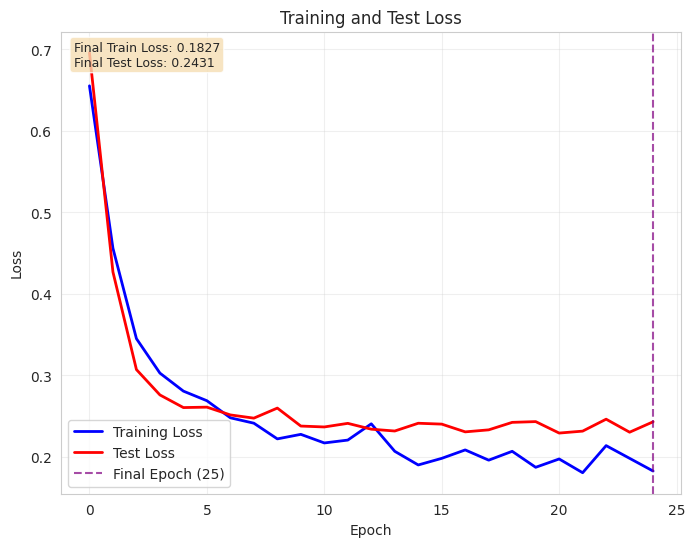

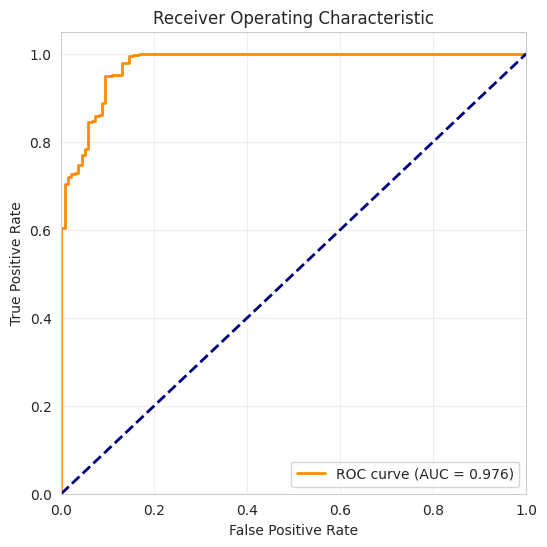

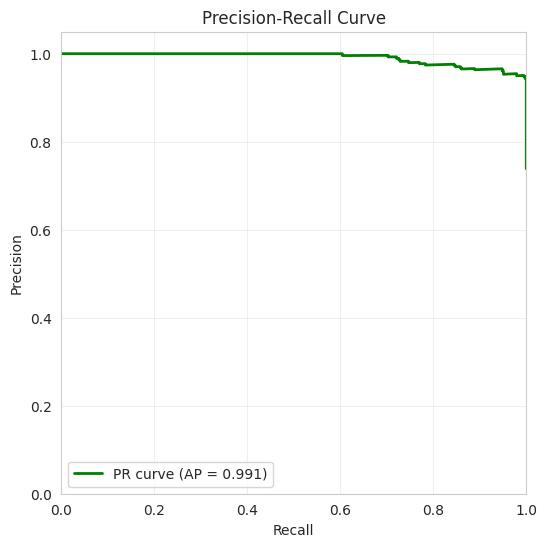

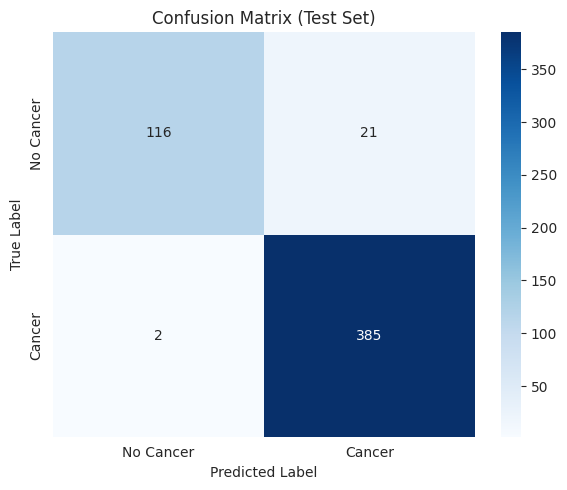

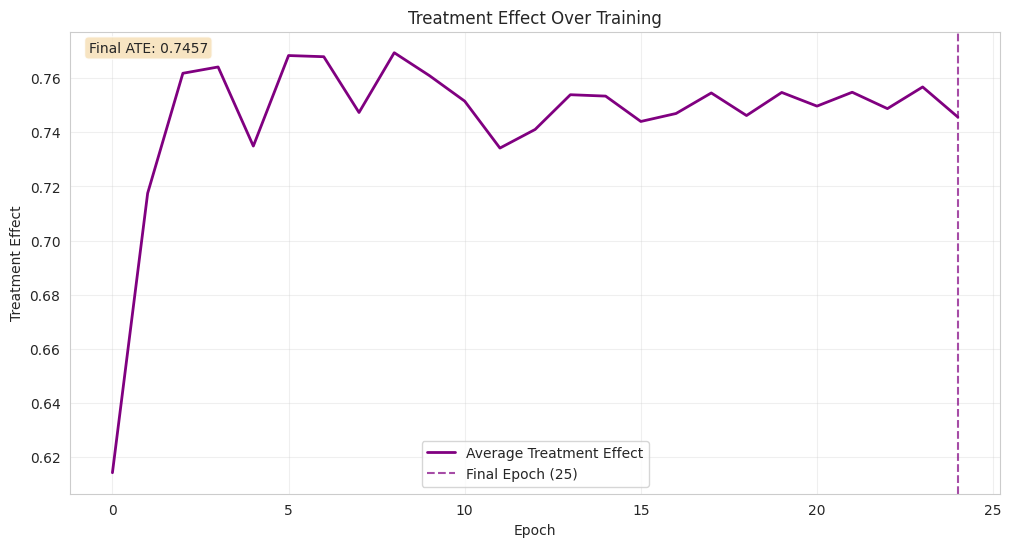


COMPREHENSIVE TRAINING SUMMARY
   • Training Loss: 0.182675
   • Test Loss: 0.243112
   • Training Accuracy: 0.9643
   • Test Accuracy: 0.9561
   • Final Learning Rate: 0.00100000
   • Final Treatment Effect: 0.745654

TREATMENT EFFECT ANALYSIS
Average Treatment Effects for 3 treatments:
  Treatment 0: 0.7449 ± 0.4066 (95% CI: [-0.0520, 1.5417])
  Treatment 1: 0.7468 ± 0.4075 (95% CI: [-0.0518, 1.5454])
  Treatment 2: 0.7453 ± 0.4067 (95% CI: [-0.0518, 1.5425])

Treatment Effect Comparisons:
  Treatment 0 vs 1: -0.0019
  Treatment 0 vs 2: -0.0005
  Treatment 1 vs 2: +0.0015


In [18]:
# Step 7: Enhanced Training Process Visualization (4 independent plots with saving)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix
import os

save_dir = 'saved_figures'
os.makedirs(save_dir, exist_ok=True)

# Compute ROC and PR metrics (using test set predictions)
if 'test_pred_proba' not in locals():
    model.eval()
    with torch.no_grad():
        fixed_treatment = torch.tensor([1., 0., 0.], device=device)
        fixed_treatment_test = fixed_treatment.unsqueeze(0).repeat(X_test_tensor.shape[0], 1)
        test_outputs_dict = model(X_test_tensor, fixed_treatment_test, return_components=True)
        test_pred_proba = np.array(test_outputs_dict['treatment_effect'].cpu().tolist()).flatten()
        y_test_values = y_test.values.astype(int).flatten()

fpr, tpr, _ = roc_curve(y_test_values, test_pred_proba)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_values, test_pred_proba)
pr_auc = average_precision_score(y_test_values, test_pred_proba)
cm = confusion_matrix(y_test_values, (test_pred_proba > 0.5).astype(int))

# Loss
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Training Loss', linewidth=2, color='blue')
plt.plot(test_losses, label='Test Loss', linewidth=2, color='red')
if len(train_losses) > 0:
    final_epoch = len(train_losses) - 1
    plt.axvline(x=final_epoch, color='purple', linestyle='--', alpha=0.7,
                label=f'Final Epoch ({final_epoch+1})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()
plt.grid(True, alpha=0.3)
if len(train_losses) > 0:
    textstr = f'Final Train Loss: {train_losses[-1]:.4f}\nFinal Test Loss: {test_losses[-1]:.4f}'
    plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=9,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.savefig(os.path.join(save_dir, 'loss_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

# ROC
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(save_dir, 'roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

# PR
plt.figure(figsize=(6, 6))
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AP = {pr_auc:.3f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(save_dir, 'pr_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Cancer', 'Cancer'], yticklabels=['No Cancer', 'Cancer'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# Treatment Effect Analysis
plt.figure(figsize=(12, 6))
plt.plot(treatment_effects, label='Average Treatment Effect', linewidth=2, color='purple')
if len(treatment_effects) > 0:
    final_epoch = len(treatment_effects) - 1
    plt.axvline(x=final_epoch, color='purple', linestyle='--', alpha=0.7,
                label=f'Final Epoch ({final_epoch+1})')
plt.xlabel('Epoch')
plt.ylabel('Treatment Effect')
plt.title('Treatment Effect Over Training')
plt.legend()
plt.grid(True, alpha=0.3)
if len(treatment_effects) > 0:
    final_ate = treatment_effects[-1]
    textstr = f'Final ATE: {final_ate:.4f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=props)
plt.savefig(os.path.join(save_dir, 'treatment_effect.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print summary 
print("\n" + "="*80)
print("COMPREHENSIVE TRAINING SUMMARY")
print("="*80)

if len(train_losses) > 0:
    final_epoch = len(train_losses)
    print(f"   • Training Loss: {train_losses[-1]:.6f}")
    print(f"   • Test Loss: {test_losses[-1]:.6f}")
    print(f"   • Training Accuracy: {train_accuracies[-1]:.4f}")
    print(f"   • Test Accuracy: {test_accuracies[-1]:.4f}")
    print(f"   • Final Learning Rate: {learning_rates[-1]:.8f}")
    print(f"   • Final Treatment Effect: {treatment_effects[-1]:.6f}")

print("\n" + "="*80)
print("TREATMENT EFFECT ANALYSIS")
print("="*80)

model.eval()
with torch.no_grad():
    final_ate = model.estimate_ate(X_test_tensor)
    print(f"Average Treatment Effects for {final_ate.shape[1]} treatments:")
    for i in range(final_ate.shape[1]):
        ate_values = final_ate[:, i]
        ate_mean = ate_values.mean().item()
        ate_std = ate_values.std().item()
        print(f"  Treatment {i}: {ate_mean:.4f} ± {ate_std:.4f} (95% CI: [{ate_mean-1.96*ate_std:.4f}, {ate_mean+1.96*ate_std:.4f}])")
    
    if final_ate.shape[1] >= 2:
        print(f"\nTreatment Effect Comparisons:")
        for i in range(final_ate.shape[1]):
            for j in range(i+1, final_ate.shape[1]):
                diff = (final_ate[:, i] - final_ate[:, j]).mean().item()
                print(f"  Treatment {i} vs {j}: {diff:+.4f}")

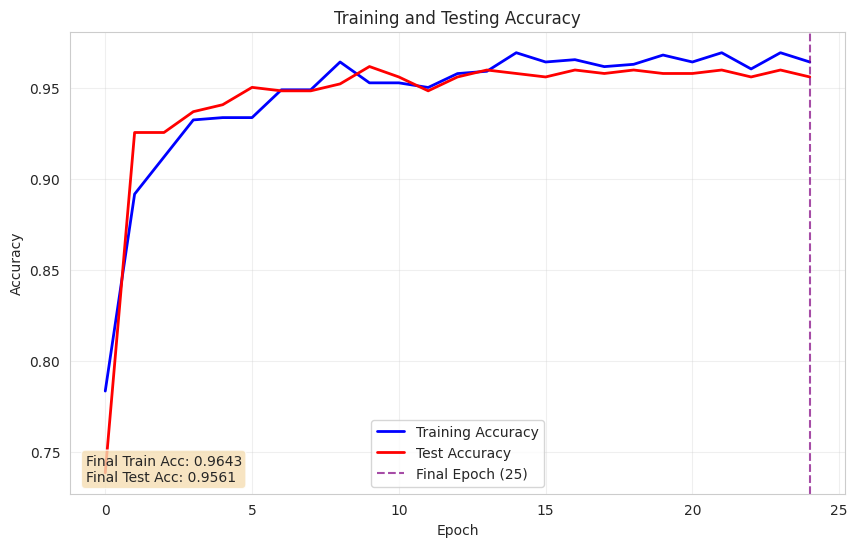

In [19]:
#Training and Test Accurancy
plt.figure(figsize=(10, 6))
plt.plot(train_accuracies, label='Training Accuracy', linewidth=2, color='blue')
plt.plot(test_accuracies, label='Test Accuracy', linewidth=2, color='red')
if len(train_accuracies) > 0:
    final_epoch = len(train_accuracies) - 1
    plt.axvline(x=final_epoch, color='purple', linestyle='--', alpha=0.7,
                label=f'Final Epoch ({final_epoch+1})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
if len(train_accuracies) > 0:
    textstr = f'Final Train Acc: {train_accuracies[-1]:.4f}\nFinal Test Acc: {test_accuracies[-1]:.4f}'
    plt.text(0.02, 0.02, textstr, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.show()

#Model Evaluation

In [20]:
import numpy as np
import torch

test_tensor = torch.tensor([1.0])
test_list = test_tensor.cpu().tolist()
test_arr = np.array(test_list)
print(test_arr)

[1.]


In [21]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Step 8: Enhanced Model Evaluation
model.eval()
with torch.no_grad():    
    fixed_treatment = torch.tensor([1., 0., 0.], device=device)
    fixed_treatment_train = fixed_treatment.unsqueeze(0).repeat(X_train_tensor.shape[0], 1)
    fixed_treatment_test = fixed_treatment.unsqueeze(0).repeat(X_test_tensor.shape[0], 1)

    train_outputs_dict = model(X_train_tensor, fixed_treatment_train, return_components=True)
    test_outputs_dict = model(X_test_tensor, fixed_treatment_test, return_components=True)

    train_pred_proba = np.array(train_outputs_dict['treatment_effect'].cpu().tolist())
    test_pred_proba = np.array(test_outputs_dict['treatment_effect'].cpu().tolist())   # 修改这里

    train_pred = (train_pred_proba > 0.5).astype(int).flatten()
    test_pred = (test_pred_proba > 0.5).astype(int).flatten()

y_train_values = y_train.values.astype(int).flatten()
y_test_values = y_test.values.astype(int).flatten()

print(f"Shapes - Train pred: {train_pred.shape}, labels: {y_train_values.shape}")
print(f"Shapes - Test pred: {test_pred.shape}, labels: {y_test_values.shape}")

def calculate_metrics(y_true, y_pred, y_proba):
    y_true = y_true.flatten() if hasattr(y_true, 'flatten') else y_true
    y_pred = y_pred.flatten() if hasattr(y_pred, 'flatten') else y_pred
    y_proba = y_proba.flatten() if hasattr(y_proba, 'flatten') else y_proba

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    if len(np.unique(y_true)) > 1: 
        auc_roc = roc_auc_score(y_true, y_proba)
    else:
        auc_roc = 0.0
        print("Warning: Only one class present in y_true. AUC-ROC set to 0.")

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc_roc
    }

train_metrics = calculate_metrics(y_train_values, train_pred, train_pred_proba)
test_metrics = calculate_metrics(y_test_values, test_pred, test_pred_proba)

metrics_df = pd.DataFrame({
    'Training Set': train_metrics,
    'Test Set': test_metrics
}).round(4)

print("Enhanced Model Performance Metrics:")
print(metrics_df)

Shapes - Train pred: (785,), labels: (785,)
Shapes - Test pred: (524,), labels: (524,)
Enhanced Model Performance Metrics:
           Training Set  Test Set
Accuracy         0.9707    0.9561
Precision        0.9649    0.9483
Recall           0.9966    0.9948
F1-Score         0.9805    0.9710
AUC-ROC          0.9951    0.9765


#Final Visualizations and Reports

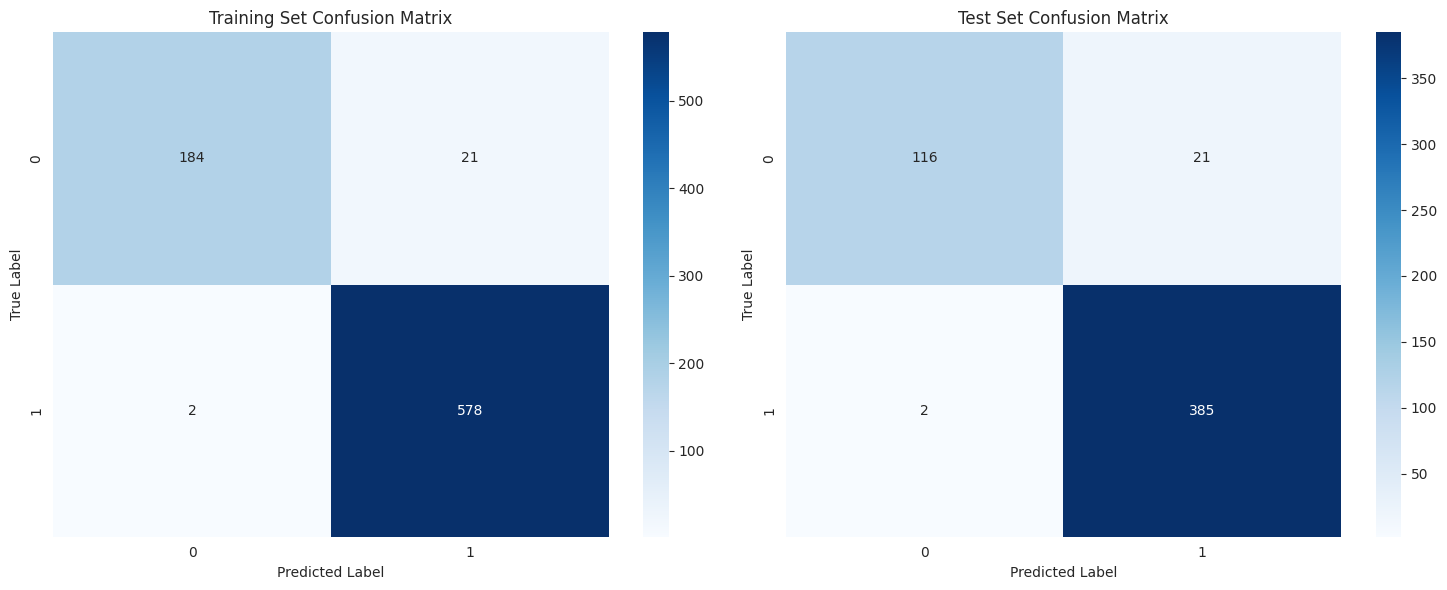


Training Set Classification Report:
              precision    recall  f1-score   support

   No Cancer       0.99      0.90      0.94       205
      Cancer       0.96      1.00      0.98       580

    accuracy                           0.97       785
   macro avg       0.98      0.95      0.96       785
weighted avg       0.97      0.97      0.97       785


Test Set Classification Report:
              precision    recall  f1-score   support

   No Cancer       0.98      0.85      0.91       137
      Cancer       0.95      0.99      0.97       387

    accuracy                           0.96       524
   macro avg       0.97      0.92      0.94       524
weighted avg       0.96      0.96      0.95       524


Final Enhanced Model Performance:
- Training Accuracy: 0.9707
- Test Accuracy: 0.9561
- Test AUC-ROC: 0.9765
- Combined dataset size: 1309 samples
- Training set: 785 samples (60.0%)
- Test set: 524 samples (40.0%)


In [22]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Training set confusion matrix
cm_train = confusion_matrix(y_train_values, train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Training Set Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Test set confusion matrix
cm_test = confusion_matrix(y_test_values, test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Test Set Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Classification reports
print("\nTraining Set Classification Report:")
print(classification_report(y_train_values, train_pred, target_names=['No Cancer', 'Cancer']))

print("\nTest Set Classification Report:")
print(classification_report(y_test_values, test_pred, target_names=['No Cancer', 'Cancer']))

# Performance summary
print(f"\nFinal Enhanced Model Performance:")
print(f"- Training Accuracy: {train_metrics['Accuracy']:.4f}")
print(f"- Test Accuracy: {test_metrics['Accuracy']:.4f}")
print(f"- Test AUC-ROC: {test_metrics['AUC-ROC']:.4f}")
print(f"- Combined dataset size: {combined_df.shape[0]} samples")
print(f"- Training set: {X_train.shape[0]} samples ({X_train.shape[0]/combined_df.shape[0]*100:.1f}%)")
print(f"- Test set: {X_test.shape[0]} samples ({X_test.shape[0]/combined_df.shape[0]*100:.1f}%)")

#shap

In [23]:
!pip install shap

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


Preparing background data...
Using 50 background samples
Initializing SHAP KernelExplainer for 100 test samples...


100%|██████████| 100/100 [00:01<00:00, 69.31it/s]



Generating SHAP visualizations (displayed in notebook)...



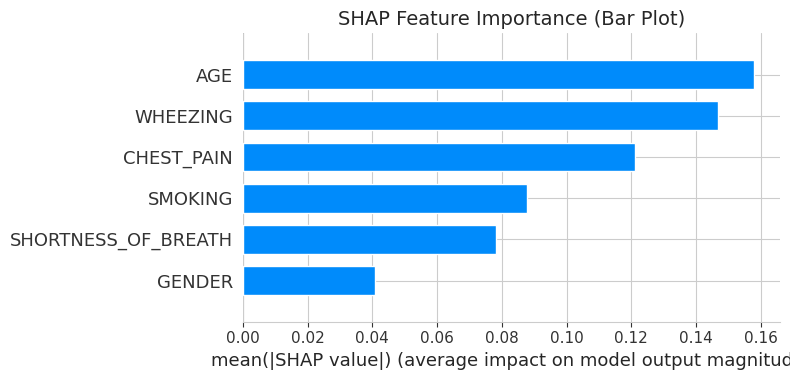

Plot 1: Feature Importance Bar Plot displayed



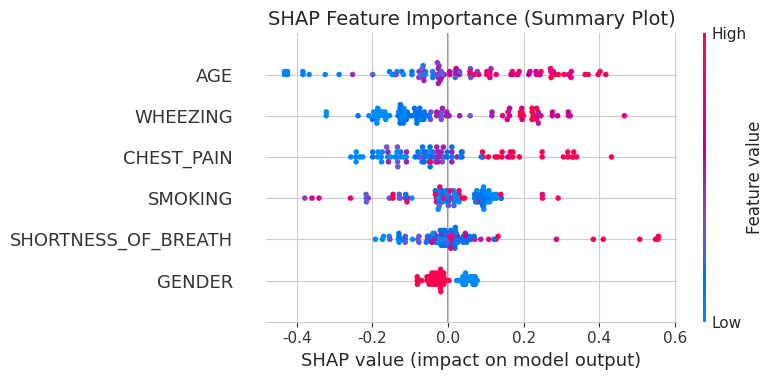

Plot 2: Feature Importance Summary Plot displayed



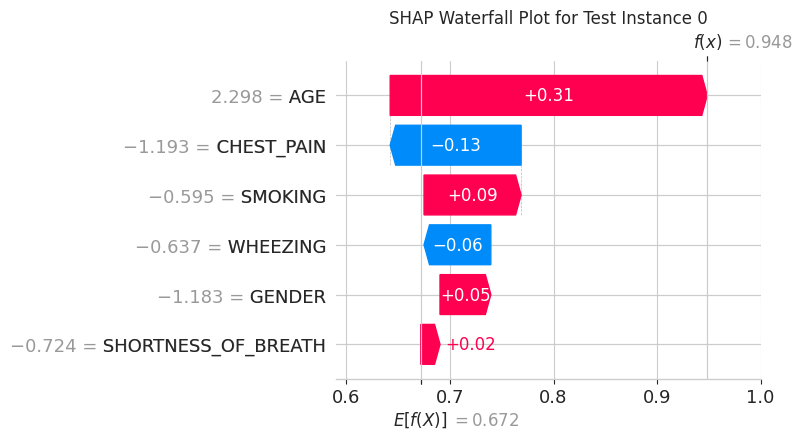

Plot 3: Waterfall Plot displayed



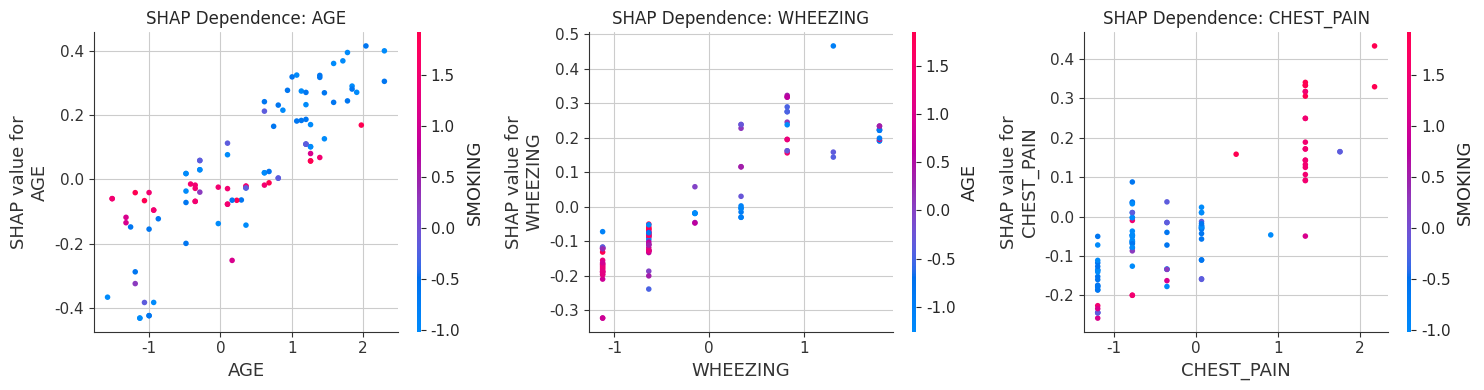

Plot 4: Dependence Plots displayed



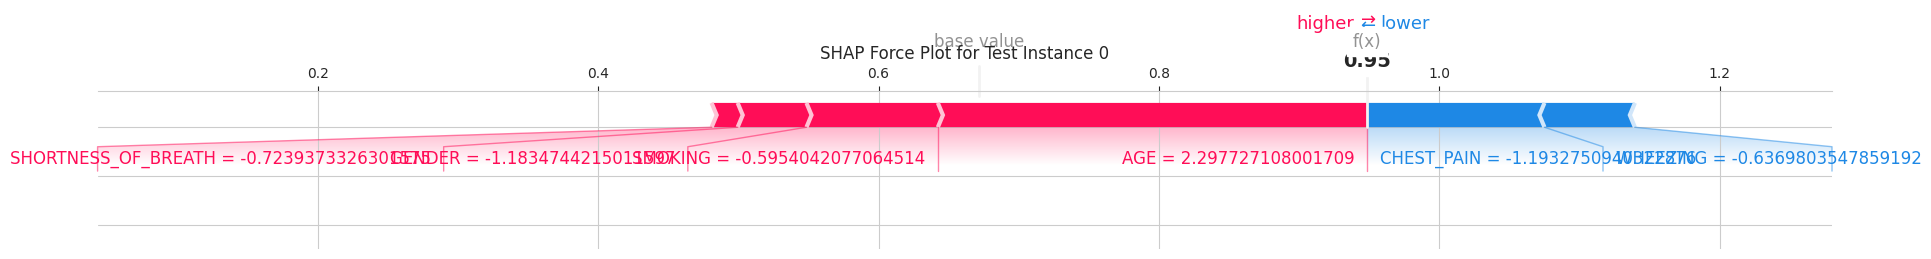

Plot 5: Force Plot displayed


SHAP ANALYSIS SUMMARY
Top 10 Most Important Features:
    Feature   Mean_ABS_SHAP
    AGE             0.158026
    WHEEZING        0.146754
    CHEST_PAIN      0.121259
    SMOKING         0.087790
    SHORTNESS_OF_BREATH 0.078123
    GENDER          0.040921

SHAP Statistics:
- Total impact magnitude: 0.6329
- Average impact per feature: 0.1055
- Most impactful feature: AGE (impact: 0.158026)

Feature Effect Analysis:
- AGE: increases cancer risk (avg impact: 0.033528)
- WHEEZING: decreases cancer risk (avg impact: -0.005128)
- CHEST_PAIN: decreases cancer risk (avg impact: -0.014540)
- SMOKING: increases cancer risk (avg impact: 0.008296)
- SHORTNESS_OF_BREATH: increases cancer risk (avg impact: 0.017345)
- GENDER: decreases cancer risk (avg impact: -0.003325)

SHAP analysis completed! All plots displayed in the notebook.


In [24]:
# ============================================================================
# SHAP Analysis for Model Interpretability (English version, plots in notebook)
# ============================================================================

import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import os

# Ensure model is in evaluation mode
model.eval()

# Select background data and test data for SHAP
background_size = 50
test_sample_size = 100

# Randomly select background samples from training set (fixed random seed)
np.random.seed(42)
bg_indices = np.random.choice(X_train_scaled.shape[0], background_size, replace=False)
background_data = X_train_scaled[bg_indices]

# Randomly select samples for interpretation from test set
test_indices = np.random.choice(X_test_scaled.shape[0], test_sample_size, replace=False)
test_data = X_test_scaled[test_indices]

print("Preparing background data...")
print(f"Using {background_size} background samples")
print(f"Initializing SHAP KernelExplainer for {test_sample_size} test samples...")

# Define prediction function (using the same fixed treatment as in evaluation)
fixed_treatment = torch.tensor([1., 0., 0.], device=device)

def predict_proba(X):
    """
    X: numpy array of shape (n_samples, n_features)
    Returns: 1D array of predicted probabilities
    """
    X_tensor = torch.FloatTensor(X).to(device)
    batch_size = X_tensor.shape[0]
    treatment_batch = fixed_treatment.unsqueeze(0).repeat(batch_size, 1)
    with torch.no_grad():
        outputs = model(X_tensor, treatment_batch)   # shape (batch_size, 1)
        # Use tolist() to avoid numpy compatibility issues
        prob = np.array(outputs.cpu().tolist()).flatten()
    return prob

# Use KernelExplainer
explainer = shap.KernelExplainer(predict_proba, background_data)

# Compute SHAP values (progress bar will appear, may take some seconds/minutes)
shap_values = explainer.shap_values(test_data, nsamples=100)

# If shap_values is a list (e.g., two classes for binary classification), take the positive class
if isinstance(shap_values, list):
    shap_values = shap_values[1]

feature_names = common_features

print("\nGenerating SHAP visualizations (displayed in notebook)...\n")

# ============================================================================
# Plot 1: Feature Importance Bar Plot
# ============================================================================
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, test_data, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar Plot)", fontsize=14)
plt.tight_layout()
plt.show()
print("Plot 1: Feature Importance Bar Plot displayed\n")

# ============================================================================
# Plot 2: Feature Importance Summary Plot (dot plot)
# ============================================================================
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, test_data, feature_names=feature_names, show=False)
plt.title("SHAP Feature Importance (Summary Plot)", fontsize=14)
plt.tight_layout()
plt.show()
print("Plot 2: Feature Importance Summary Plot displayed\n")

# ============================================================================
# Plot 3: Waterfall Plot (first test instance)
# ============================================================================
plt.figure(figsize=(12, 4))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=test_data[0],
        feature_names=feature_names
    ),
    show=False
)
plt.title(f"SHAP Waterfall Plot for Test Instance 0", fontsize=12)
plt.tight_layout()
plt.show()
print("Plot 3: Waterfall Plot displayed\n")

# ============================================================================
# Plot 4: Dependence Plots (top 3 features)
# ============================================================================
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
top_indices = np.argsort(mean_abs_shap)[::-1][:3]
top_features = [feature_names[i] for i in top_indices]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, idx in enumerate(top_indices):
    shap.dependence_plot(
        idx, shap_values, test_data,
        feature_names=feature_names,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f"SHAP Dependence: {feature_names[idx]}")
plt.tight_layout()
plt.show()
print("Plot 4: Dependence Plots displayed\n")

# ============================================================================
# Plot 5: Force Plot (first test instance, static matplotlib version)
# ============================================================================
shap.initjs()  # for interactive force plots in notebook (optional)
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[0,:],
    test_data[0,:],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.title("SHAP Force Plot for Test Instance 0", fontsize=12)
plt.tight_layout()
plt.show()
print("Plot 5: Force Plot displayed\n")

# ============================================================================
# Optional: Save feature importance table (still saved, but plots shown in notebook)
# ============================================================================
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_ABS_SHAP': mean_abs_shap,
    'Mean_SHAP': np.mean(shap_values, axis=0),
    'Std_SHAP': np.std(shap_values, axis=0)
}).sort_values('Mean_ABS_SHAP', ascending=False)

print("\n" + "="*80)
print("SHAP ANALYSIS SUMMARY")
print("="*80)
print("Top 10 Most Important Features:")
print("    Feature   Mean_ABS_SHAP")
for _, row in importance_df.head(10).iterrows():
    print(f"    {row['Feature']:<15} {row['Mean_ABS_SHAP']:.6f}")

print("\nSHAP Statistics:")
print(f"- Total impact magnitude: {np.sum(mean_abs_shap):.4f}")
print(f"- Average impact per feature: {np.mean(mean_abs_shap):.4f}")
most_impactful = importance_df.iloc[0]
print(f"- Most impactful feature: {most_impactful['Feature']} (impact: {most_impactful['Mean_ABS_SHAP']:.6f})")

print("\nFeature Effect Analysis:")
for _, row in importance_df.iterrows():
    direction = "increases" if row['Mean_SHAP'] > 0 else "decreases"
    print(f"- {row['Feature']}: {direction} cancer risk (avg impact: {row['Mean_SHAP']:.6f})")

print("\nSHAP analysis completed! All plots displayed in the notebook.")

In [25]:
import joblib
import numpy as np

torch.save(model.state_dict(), 'model_weights.pth')

joblib.dump(scaler, 'scaler.pkl')

np.savez('test_data.npz', X_test_scaled=X_test_scaled, y_test=y_test)

joblib.dump(feature_names, 'feature_names.pkl')

['feature_names.pkl']

In [26]:
pip install --upgrade typing_extensions

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


In [27]:
!pip install openai

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [28]:
!pip install socksio

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [29]:
!pip install --upgrade --force-reinstall typing_extensions

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 4.5 MB/s eta 0:00:00
  Attempting uninstall: typing_extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_extensions-4.15.0:
      Successfully uninstalled typing_extensions-4.15.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.1 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.4.4 which is incompatible.


In [30]:
import openai
print(openai.__version__)   # Should output something like 1.70.0

2.31.0


In [31]:
import openai
import re
import pandas as pd

In [32]:
# ================== 1. Configure DeepSeek API ==================
DEEPSEEK_API_KEY = "sk-09de19c62e754ed3a7be9012fd7ab154"  
client = openai.OpenAI(
    api_key=DEEPSEEK_API_KEY,
    base_url="https://api.deepseek.com"
)

# ================== 2. Medical knowledge base (extendable) ==================
medical_knowledge = {
    "WHEEZING": (
        "Wheezing is a common sign of airway narrowing or obstruction. In lung cancer patients, "
        "tumor compression of the airways or local inflammation can cause wheezing."
    ),
    "SMOKING": (
        "Smoking is the leading risk factor for lung cancer. Carcinogens in tobacco, such as tar, "
        "nicotine, and polycyclic aromatic hydrocarbons, damage DNA in lung epithelial cells, "
        "triggering mutations that promote cancer growth."
    ),
    "AGE": (
        "Age is a major risk factor for many cancers. As we age, DNA repair mechanisms become less "
        "efficient, allowing mutations to accumulate, which increases the probability of developing cancer."
    ),
    "CHEST_PAIN": (
        "Chest pain can result from tumor invasion of the pleura, ribs, or nerve compression. "
        "Persistent chest pain is a common symptom of lung cancer, especially when the tumor is large "
        "or has metastasized to the chest wall."
    ),
    "SHORTNESS_OF_BREATH": (
        "Shortness of breath (dyspnea) often occurs due to airway obstruction, pleural effusion, "
        "or atelectasis caused by the tumor. Involvement of the phrenic nerve can also lead to "
        "diaphragmatic paralysis, worsening breathing difficulties."
    ),
    "GENDER": (
        "Gender influences lung cancer risk. Men have historically higher smoking rates, but women "
        "who never smoke also face elevated risks, possibly due to hormonal factors, genetic susceptibility, "
        "or exposure to secondhand smoke."
    )
}

# ================== 3. Retrieval function ==================
def retrieve_knowledge(importance_df, top_k=3):
    """Retrieve medical knowledge for the top_k most important features."""
    top_features = importance_df.head(top_k)['Feature'].tolist()
    context = "【Relevant Medical Knowledge】\n"
    for feat in top_features:
        if feat in medical_knowledge:
            context += f"- {feat}: {medical_knowledge[feat]}\n"
        else:
            context += f"- {feat}: (No detailed medical explanation available)\n"
    return context

# ================== 4. Build prompt with RAG ==================
def build_prompt(importance_df, top_k=5):
    """Construct a prompt that includes feature importance and retrieved medical knowledge."""
    knowledge_context = retrieve_knowledge(importance_df, top_k=3)
    top_features_table = importance_df.head(top_k).to_string(index=False)

    prompt = f"""
You are a medical AI explanation expert. Using the medical knowledge provided, generate an accessible yet professional explanation of the lung cancer risk prediction model.

{knowledge_context}

【Feature Importance】(sorted by mean |SHAP value|):
{top_features_table}

In your explanation, please cover:
1. Which features have the greatest impact on the prediction?
2. How do these features influence lung cancer risk (increase or decrease)?
3. Based on the provided medical knowledge, explain why these features are so important.
4. Conclude with a summary that helps patients or doctors understand the model's decision-making.

The answer should be fluent, easy to understand, and maintain a professional tone.
"""
    return prompt

# ================== 5. Call LLM to generate explanation ==================
def generate_explanation(importance_df, top_k=5):
    """Use DeepSeek API to generate a model explanation with RAG."""
    prompt = build_prompt(importance_df, top_k)
    try:
        response = client.chat.completions.create(
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "You are a professional medical AI explanation assistant, skilled at translating complex model predictions into plain language."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.7,
            max_tokens=800
        )
        explanation = response.choices[0].message.content
    except Exception as e:
        explanation = f"LLM call failed: {str(e)}\nPlease check your API key and network connection."
    return explanation

# ================== 6. Clean Markdown formatting ==================
def clean_markdown(text):
    """Remove common Markdown formatting symbols while preserving content."""
    # Remove bold/italic markers
    text = re.sub(r'\*\*([^*]+)\*\*', r'\1', text)   # **bold**
    text = re.sub(r'\*([^*]+)\*', r'\1', text)       # *italic*
    # Remove headings (e.g., ### Title)
    text = re.sub(r'^#{1,6}\s+', '', text, flags=re.MULTILINE)
    # Remove list markers (e.g., -, *, 1.)
    text = re.sub(r'^[\s]*[-*]\s+', '', text, flags=re.MULTILINE)
    text = re.sub(r'^\d+\.\s+', '', text, flags=re.MULTILINE)
    # Remove backticks
    text = re.sub(r'`([^`]+)`', r'\1', text)
    return text.strip()

# ================== 7. Execute ==================
# Ensure importance_df is available from previous SHAP analysis
if 'importance_df' in locals() or 'importance_df' in globals():
    llm_explanation = generate_explanation(importance_df, top_k=5)
    plain_explanation = clean_markdown(llm_explanation)
    
    print("\n" + "="*80)
    print("RAG‑Enhanced Model Explanation (Plain Text):")
    print("="*80)
    print(plain_explanation)
else:
    print("Error: 'importance_df' not found. Please run SHAP analysis first to generate the feature importance dataframe.")


RAG‑Enhanced Model Explanation (Plain Text):
Understanding Your Lung Cancer Risk Prediction Model

This explanation is designed to help you understand how the AI model assesses lung cancer risk based on key health factors. The model analyzes specific features—such as age, symptoms, and habits—to estimate an individual's likelihood of developing lung cancer. Below, I break down the most influential features, how they affect risk, and the medical reasoning behind their importance.

Which Features Have the Greatest Impact?
The model identifies AGE, WHEEZING, and CHEST_PAIN as the top three features influencing lung cancer risk predictions. These are followed by SMOKING and SHORTNESS_OF_BREATH, which also contribute significantly but to a lesser degree.

How Do These Features Influence Risk?
AGE: Generally increases risk. As age rises, so does the predicted likelihood of lung cancer.
WHEEZING: Slightly decreases risk on average, but its impact varies widely—it can signal airway issues tha

In [33]:
!{sys.executable} -m pip install --upgrade typing-extensions openai pydantic

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [34]:
!pip freeze > requirements.txt